<a href="https://www.kaggle.com/code/romeoshaffun/people-and-car-object-detection?scriptVersionId=301668363" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install ultralytics -q

import os, json, shutil, random, kagglehub
import pandas as pd
import numpy as np
from PIL import Image
from ultralytics import YOLO

BASE        = "/kaggle/input/datasets"
FACE_PATH   = kagglehub.dataset_download("fareselmenshawii/face-detection-dataset")
PLATE_PATH  = kagglehub.dataset_download("linkgish/indonesian-plate-number-from-multi-sources")
PEOPLE_PATH = kagglehub.dataset_download("adilshamim8/people-detection")
CAR_PATH    = kagglehub.dataset_download("sshikamaru/car-object-detection")
WORK        = "/kaggle/working"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.5 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
BASE        = "/kaggle/input/datasets"
FACE_PATH   = f"{BASE}/fareselmenshawii/face-detection-dataset"
PLATE_PATH  = f"{BASE}/linkgish/indonesian-plate-number-from-multi-sources/plate_detection_dataset/plate_detection_dataset"
PEOPLE_PATH = f"{BASE}/adilshamim8/people-detection"
CAR_PATH    = f"{BASE}/sshikamaru/car-object-detection/data"
WORK        = "/kaggle/working"

In [3]:
for split in ["train", "val"]:
    os.makedirs(f"{WORK}/primary/images/{split}", exist_ok=True)
    os.makedirs(f"{WORK}/primary/labels/{split}", exist_ok=True)

def csv_to_yolo(csv_path, img_dir, out_img_dir, out_lbl_dir, class_id, prefix):
    df = pd.read_csv(csv_path)
    grouped = df.groupby("filename")
    for img_name, rows in grouped:
        img_src = os.path.join(img_dir, img_name)
        if not os.path.exists(img_src):
            continue
        img = Image.open(img_src)
        W, H = img.size
        shutil.copy(img_src, os.path.join(out_img_dir, f"{prefix}_{img_name}"))
        label_name = os.path.splitext(img_name)[0] + ".txt"
        with open(os.path.join(out_lbl_dir, f"{prefix}_{label_name}"), "w") as f:
            for _, row in rows.iterrows():
                xc = ((row.xmin + row.xmax) / 2) / W
                yc = ((row.ymin + row.ymax) / 2) / H
                w  = (row.xmax - row.xmin) / W
                h  = (row.ymax - row.ymin) / H
                f.write(f"{class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

# --- CAR (class 0): manual train/val split from single CSV ---
car_df    = pd.read_csv(f"{CAR_PATH}/train_solution_bounding_boxes (1).csv")
car_imgs  = car_df["image"].unique().tolist()
random.shuffle(car_imgs)
split_idx = int(0.85 * len(car_imgs))
car_train, car_val = car_imgs[:split_idx], car_imgs[split_idx:]

car_train_df = car_df[car_df["image"].isin(car_train)].rename(columns={"image": "filename"})
car_val_df   = car_df[car_df["image"].isin(car_val)].rename(columns={"image": "filename"})

car_train_df.to_csv(f"{WORK}/car_train_tmp.csv", index=False)
car_val_df.to_csv(f"{WORK}/car_val_tmp.csv",     index=False)

csv_to_yolo(f"{WORK}/car_train_tmp.csv", f"{CAR_PATH}/training_images",
            f"{WORK}/primary/images/train", f"{WORK}/primary/labels/train", 0, "car")
csv_to_yolo(f"{WORK}/car_val_tmp.csv",   f"{CAR_PATH}/training_images",
            f"{WORK}/primary/images/val",   f"{WORK}/primary/labels/val",   0, "car")

# --- PEOPLE (class 1): already split into train/valid ---
csv_to_yolo(f"{PEOPLE_PATH}/train/train/_annotations.csv",
            f"{PEOPLE_PATH}/train/train",
            f"{WORK}/primary/images/train", f"{WORK}/primary/labels/train", 1, "ppl")
csv_to_yolo(f"{PEOPLE_PATH}/valid/valid/_annotations.csv",
            f"{PEOPLE_PATH}/valid/valid",
            f"{WORK}/primary/images/val",   f"{WORK}/primary/labels/val",   1, "ppl")

print("Train images:", len(os.listdir(f"{WORK}/primary/images/train")))
print("Val images:  ", len(os.listdir(f"{WORK}/primary/images/val")))
print("Train labels:", len(os.listdir(f"{WORK}/primary/labels/train")))
print("Val labels:  ", len(os.listdir(f"{WORK}/primary/labels/val")))

Train images: 13579
Val images:   1424
Train labels: 13579
Val labels:   1424


In [4]:
for split in ["train", "val"]:
    os.makedirs(f"{WORK}/plate_yolo/images/{split}", exist_ok=True)
    os.makedirs(f"{WORK}/plate_yolo/labels/{split}", exist_ok=True)

with open(f"{PLATE_PATH}/annotations/annotations.json") as f:
    coco = json.load(f)

img_map = {img["id"]: img for img in coco["images"]}
ann_map = {}
for ann in coco["annotations"]:
    ann_map.setdefault(ann["image_id"], []).append(ann)

img_ids   = list(img_map.keys())
random.shuffle(img_ids)
split_idx = int(0.85 * len(img_ids))
train_ids = img_ids[:split_idx]
val_ids   = img_ids[split_idx:]

def convert_plate(img_id, split):
    img_info  = img_map[img_id]
    file_name = img_info["file_name"]
    W, H      = int(img_info["width"]), int(img_info["height"])  # ← fix: cast to int
    img_src   = f"{PLATE_PATH}/images/{file_name}"
    if not os.path.exists(img_src):
        return
    shutil.copy(img_src, f"{WORK}/plate_yolo/images/{split}/{file_name}")
    anns       = ann_map.get(img_id, [])
    label_name = os.path.splitext(file_name)[0] + ".txt"
    with open(f"{WORK}/plate_yolo/labels/{split}/{label_name}", "w") as f:
        for ann in anns:
            x, y, w, h = [float(v) for v in ann["bbox"]]  # ← fix: cast bbox values to float
            xc = (x + w / 2) / W
            yc = (y + h / 2) / H
            nw = w / W
            nh = h / H
            f.write(f"0 {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}\n")

for img_id in train_ids: convert_plate(img_id, "train")
for img_id in val_ids:   convert_plate(img_id, "val")

print("Plate train:", len(os.listdir(f"{WORK}/plate_yolo/images/train")))
print("Plate val:  ", len(os.listdir(f"{WORK}/plate_yolo/images/val")))

Plate train: 1167
Plate val:   207


In [5]:
yamls = {
    f"{WORK}/primary.yaml": {
        "path":  f"{WORK}/primary",
        "train": "images/train",
        "val":   "images/val",
        "nc":    2,
        "names": "['car', 'person']"
    },
    f"{WORK}/plate.yaml": {
        "path":  f"{WORK}/plate_yolo",
        "train": "images/train",
        "val":   "images/val",
        "nc":    1,
        "names": "['license_plate']"
    },
    f"{WORK}/face.yaml": {
        "path":  FACE_PATH,
        "train": "images/train",
        "val":   "images/val",
        "nc":    1,
        "names": "['face']"
    },
}

for path, cfg in yamls.items():
    with open(path, "w") as f:
        f.write(f"path: {cfg['path']}\n")
        f.write(f"train: {cfg['train']}\n")
        f.write(f"val: {cfg['val']}\n")
        f.write(f"nc: {cfg['nc']}\n")
        f.write(f"names: {cfg['names']}\n")
    print(f"Written: {path}")

Written: /kaggle/working/primary.yaml
Written: /kaggle/working/plate.yaml
Written: /kaggle/working/face.yaml


In [12]:
model1 = YOLO("yolov8n.pt")
model1.train(
    data=f"{WORK}/primary.yaml",
    epochs=2,
    imgsz=640,
    batch=16,
    name="primary",
    project=f"{WORK}/runs",
    save=True
)
print("Model 1 done. Weights:", f"{WORK}/runs/primary/weights/best.pt")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/primary.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=primary, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

In [13]:
model2 = YOLO("yolov8n.pt")
model2.train(
    data=f"{WORK}/plate.yaml",
    epochs=2,
    imgsz=640,
    batch=16,
    name="plate",
    project=f"{WORK}/runs",
    save=True
)
print("Model 2 done. Weights:", f"{WORK}/runs/plate/weights/best.pt")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/plate.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

In [14]:
model3 = YOLO("yolov8n.pt")
model3.train(
    data=f"{WORK}/face.yaml",
    epochs=2,
    imgsz=640,
    batch=16,
    name="face",
    project=f"{WORK}/runs",
    save=True
)
print("Model 3 done. Weights:", f"{WORK}/runs/face/weights/best.pt")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/face.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=face, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

In [15]:
import cv2

primary   = YOLO(f"{WORK}/runs/primary/weights/best.pt")
plate_det = YOLO(f"{WORK}/runs/plate/weights/best.pt")
face_det  = YOLO(f"{WORK}/runs/face/weights/best.pt")

def run_pipeline(image_path, save_path="output.jpg"):
    img     = cv2.imread(image_path)
    results = primary(img)[0]

    for box in results.boxes:
        cls          = int(box.cls)
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        roi          = img[y1:y2, x1:x2].copy()
        label        = "car" if cls == 0 else "person"
        box_color    = (0, 0, 255) if cls == 0 else (255, 165, 0)

        if cls == 0:  # car → detect plate
            for pb in plate_det(roi)[0].boxes:
                px1, py1, px2, py2 = map(int, pb.xyxy[0])
                cv2.rectangle(roi, (px1, py1), (px2, py2), (0, 255, 0), 2)
                plate_crop = roi[py1:py2, px1:px2]
                cv2.imwrite(f"{WORK}/plate_crop.jpg", plate_crop)

        elif cls == 1:  # person → detect face
            for fb in face_det(roi)[0].boxes:
                fx1, fy1, fx2, fy2 = map(int, fb.xyxy[0])
                cv2.rectangle(roi, (fx1, fy1), (fx2, fy2), (255, 0, 0), 2)
                face_crop = roi[fy1:fy2, fx1:fx2]
                cv2.imwrite(f"{WORK}/face_crop.jpg", face_crop)

        img[y1:y2, x1:x2] = roi
        cv2.rectangle(img, (x1, y1), (x2, y2), box_color, 2)
        cv2.putText(img, label, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

    cv2.imwrite(save_path, img)
    print(f"Saved: {save_path}")

In [16]:
def run_pipeline(image_path, save_path="output.jpg", crop_size=256):
    img     = cv2.imread(image_path)
    results = primary(img)[0]

    for box in results.boxes:
        cls             = int(box.cls)
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        roi             = img[y1:y2, x1:x2].copy()
        label           = "car" if cls == 0 else "person"
        box_color       = (0, 0, 255) if cls == 0 else (255, 165, 0)

        if cls == 0:  # car → detect plate
            for i, pb in enumerate(plate_det(roi)[0].boxes):
                px1, py1, px2, py2 = map(int, pb.xyxy[0])
                cv2.rectangle(roi, (px1, py1), (px2, py2), (0, 255, 0), 2)
                plate_crop = roi[py1:py2, px1:px2]
                if plate_crop.size > 0:
                    # Resize to fixed width, keep aspect ratio
                    h, w       = plate_crop.shape[:2]
                    new_w      = crop_size * 2   # plates are wide
                    new_h      = max(int(h * new_w / w), 64)
                    plate_resized = cv2.resize(plate_crop, (new_w, new_h),
                                               interpolation=cv2.INTER_CUBIC)
                    cv2.imwrite(f"{WORK}/plate_crop_{i}.jpg", plate_resized)

        elif cls == 1:  # person → detect face
            for i, fb in enumerate(face_det(roi)[0].boxes):
                fx1, fy1, fx2, fy2 = map(int, fb.xyxy[0])
                cv2.rectangle(roi, (fx1, fy1), (fx2, fy2), (255, 0, 0), 2)
                face_crop = roi[fy1:fy2, fx1:fx2]
                if face_crop.size > 0:
                    # Resize to fixed square, keep aspect ratio with padding
                    h, w      = face_crop.shape[:2]
                    scale     = crop_size / max(h, w)
                    new_w     = int(w * scale)
                    new_h     = int(h * scale)
                    resized   = cv2.resize(face_crop, (new_w, new_h),
                                           interpolation=cv2.INTER_CUBIC)
                    # Pad to exact square
                    canvas    = np.zeros((crop_size, crop_size, 3), dtype=np.uint8)
                    pad_top   = (crop_size - new_h) // 2
                    pad_left  = (crop_size - new_w) // 2
                    canvas[pad_top:pad_top+new_h, pad_left:pad_left+new_w] = resized
                    cv2.imwrite(f"{WORK}/face_crop_{i}.jpg", canvas)

        img[y1:y2, x1:x2] = roi
        cv2.rectangle(img, (x1, y1), (x2, y2), box_color, 2)
        cv2.putText(img, label, (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_color, 2)

    cv2.imwrite(save_path, img)
    print(f"Saved: {save_path}")

Testing on car image: vid_5_26660.jpg

0: 384x640 2 cars, 7.8ms
Speed: 2.6ms preprocess, 7.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 288x640 (no detections), 6.8ms
Speed: 1.3ms preprocess, 6.8ms inference, 0.6ms postprocess per image at shape (1, 3, 288, 640)

0: 384x640 (no detections), 9.9ms
Speed: 1.7ms preprocess, 9.9ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Saved: /kaggle/working/output_car.jpg


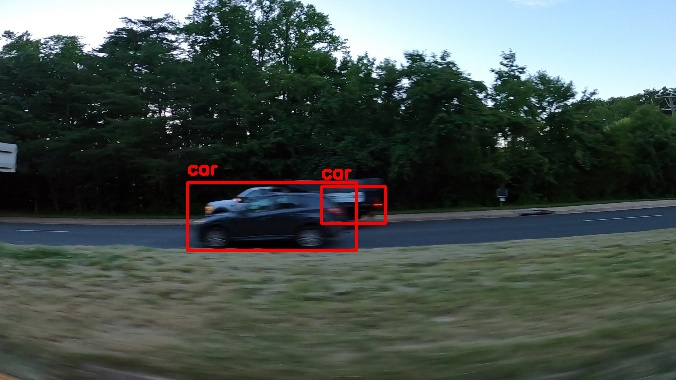

🟩 Detected 1 plate(s):


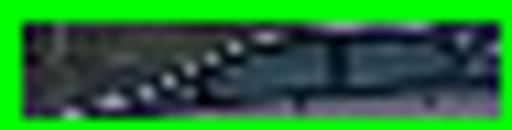


Testing on people image: 2012_000767_jpg.rf.6fa9e5f7ab6a730a0337574cd8335f3a.jpg

0: 480x640 2 persons, 7.5ms
Speed: 2.5ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 640x448 1 face, 41.3ms
Speed: 1.8ms preprocess, 41.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)

0: 608x640 (no detections), 41.2ms
Speed: 2.2ms preprocess, 41.2ms inference, 0.6ms postprocess per image at shape (1, 3, 608, 640)
Saved: /kaggle/working/output_ppl.jpg


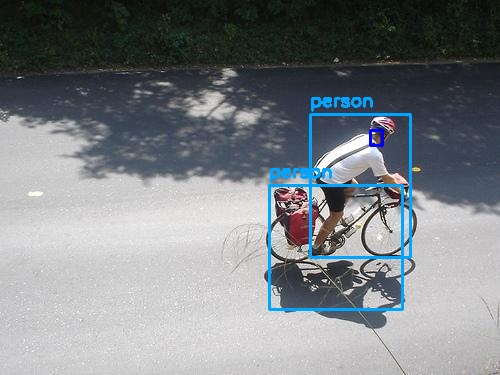

🟦 Detected 1 face(s):


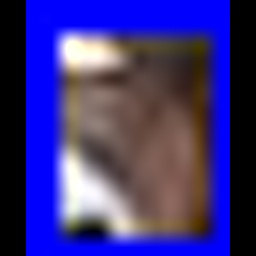

In [19]:
import random, glob
from IPython.display import Image as IPImage, display

# Pick a random car test image
test_img_car = f"{CAR_PATH}/testing_images"
sample_car   = random.choice([f for f in os.listdir(test_img_car) if f.endswith(".jpg")])
print("Testing on car image:", sample_car)
run_pipeline(f"{test_img_car}/{sample_car}", save_path=f"{WORK}/output_car.jpg")
display(IPImage(f"{WORK}/output_car.jpg"))

plate_crops = sorted(glob.glob(f"{WORK}/plate_crop_*.jpg"))
if plate_crops:
    print(f"🟩 Detected {len(plate_crops)} plate(s):")
    for p in plate_crops:
        display(IPImage(p))

# Pick a random people test image
test_img_ppl = f"{PEOPLE_PATH}/test/test"
sample_ppl   = random.choice([f for f in os.listdir(test_img_ppl) if f.endswith(".jpg")])
print("\nTesting on people image:", sample_ppl)
run_pipeline(f"{test_img_ppl}/{sample_ppl}", save_path=f"{WORK}/output_ppl.jpg")
display(IPImage(f"{WORK}/output_ppl.jpg"))

face_crops = sorted(glob.glob(f"{WORK}/face_crop_*.jpg"))
if face_crops:
    print(f"🟦 Detected {len(face_crops)} face(s):")
    for f in face_crops:
        display(IPImage(f))

Download your configs:


/kaggle/working/configs.zip